<div style="background:linear-gradient(135deg,#082f49 0%,#0369a1 55%,#38bdf8 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#bae6fd;font-weight:700;text-transform:uppercase">Chapter 130 · Time Series & Forecasting</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Forecast Accuracy</div>
  <div style="font-size:15px;color:#e0f2fe;max-width:740px;line-height:1.6">Grade forecasts fairly with the full metric family, ME, MAE, MSE, RMSE, MAPE, sMAPE, MASE, and Theil's U, see how they disagree by design, benchmark against naive, and use the Diebold-Mariano test to decide whether one model is really better than another.</div>
  <div style="margin-top:16px;font-size:13px;color:#bae6fd">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

# Forecast Accuracy
You have built many forecasts; now grade them fairly. This chapter defines the error metrics, **ME, MAE, MSE, RMSE, MAPE, sMAPE, MASE, and Theil's U**, shows how they disagree on purpose, and compares two models with the **Diebold-Mariano** test. The lesson underneath: a metric is a **loss function**, so the &#8220;best&#8221; model depends on which errors cost you the most.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns   # seaborn = high-level statistical plots (heatmaps, pairplots, count/bar plots)
from matplotlib.colors import ListedColormap
EM="#0284c7"; DEEP="#075985"; LIGHT="#bae6fd"; INK="#1a2138"; GRID="#e6e9f2"; RED="#ef4444"; AMBER="#d97706"; GREEN="#059669"; BLUE="#2563eb"; PUR="#9333ea"; GREY="#94a3b8"; SLATE="#475569"; ORG="#0284c7"; CYAN="#0891b2"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
sns.set_style("whitegrid")
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"

In [2]:
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings; warnings.filterwarnings('ignore')

<div style="background:#ecfeff;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0e7490;letter-spacing:1px">REAL DATA &#183; THREE FORECASTS, ONE HOLDOUT</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">24 months, graded head to head</div>
<div style="color:#4a5578;margin-top:6px">actuals plus three competing model forecasts.</div>
</div>

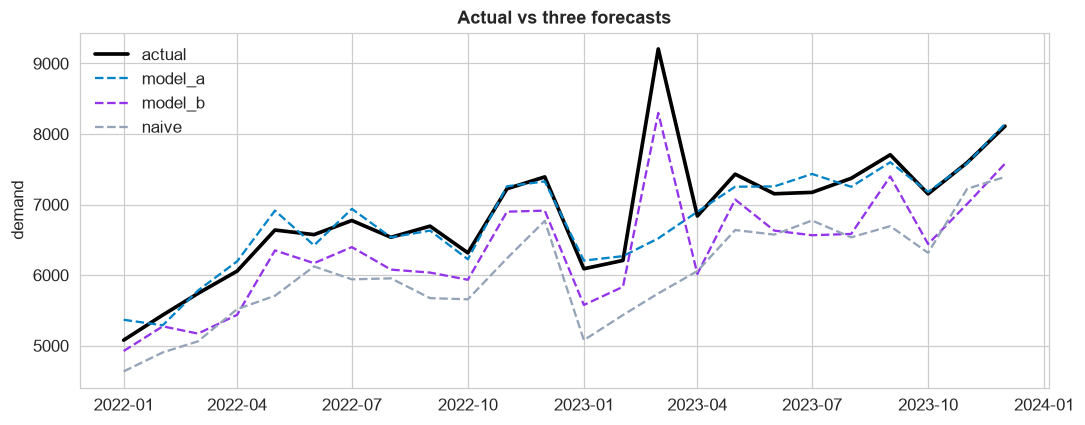

model_a tracks closely (but watch month 2022-03... it missed a spike); model_b runs low; naive lags a year behind


In [3]:
try: df = pd.read_excel('../../data/forecast-accuracy--demand_forecasts.xlsx', sheet_name='Data')
except FileNotFoundError: df = pd.read_excel(BASE + 'forecast-accuracy--demand_forecasts.xlsx', sheet_name='Data')
df['month']=pd.to_datetime(df['month']); df=df.set_index('month')
a = df['actual'].values
fig,ax=plt.subplots(figsize=(10,4)); ax.plot(df.index, a, color='k', lw=2.4, label='actual')
for c,col in zip(['model_a','model_b','naive'],[EM,PUR,GREY]): ax.plot(df.index, df[c], '--', color=col, label=c)
ax.set(title='Actual vs three forecasts', ylabel='demand'); ax.legend(); plt.tight_layout(); plt.show()
print('model_a tracks closely (but watch month 2022-03... it missed a spike); model_b runs low; naive lags a year behind')

Three forecasts of the same 24 months: <strong>model_a</strong> is accurate but <strong>missed one demand spike</strong> (a promotion), <strong>model_b</strong> runs systematically <strong>low</strong>, and <strong>naive</strong> just repeats last year. Which is best? It depends entirely on how you score them.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">DEMO 1 &#183; THE ERROR &amp; BIAS (ME)</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Start with the residual</div>
<div style="color:#4a5578;margin-top:6px">Mean Error reveals systematic bias.</div>
</div>

model_a   ME (mean error) =   +83.8
model_b   ME (mean error) =  +496.0
naive     ME (mean error) =  +827.2


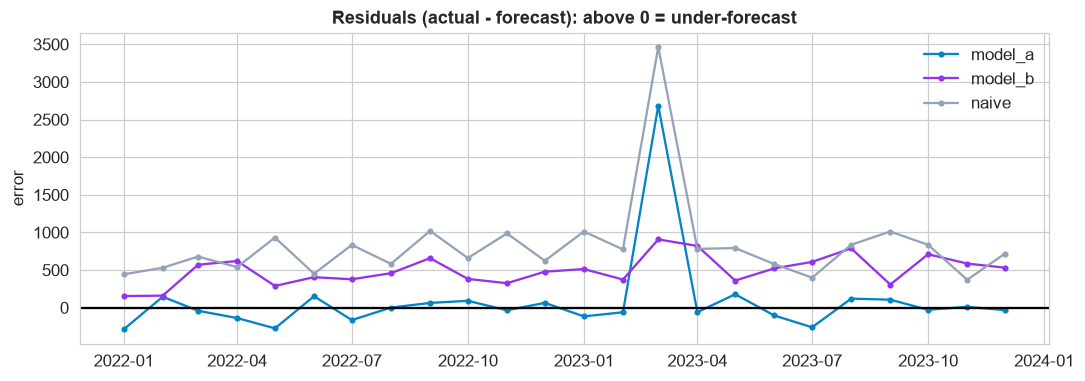

In [4]:
resid = {c: a - df[c].values for c in ['model_a','model_b','naive']}
for c,r in resid.items(): print('%-8s  ME (mean error) = %+7.1f' % (c, r.mean()))
fig,ax=plt.subplots(figsize=(10,3.6))
for c,col in zip(resid,[EM,PUR,GREY]): ax.plot(df.index, resid[c], 'o-', color=col, ms=3, label=c)
ax.axhline(0,color='k'); ax.set(title='Residuals (actual - forecast): above 0 = under-forecast', ylabel='error'); ax.legend(); plt.tight_layout(); plt.show()

The <strong>residual</strong> is <code>actual - forecast</code>. The <strong>Mean Error (ME)</strong> averages them, so it measures <strong>bias</strong>, not accuracy. model_a's ME is near zero (errors cancel), but model_b (+496) and naive (+827) sit well above zero: they <strong>systematically under-forecast</strong>. A near-zero ME can still hide big errors that cancel, so ME alone is never enough, it only catches a lean.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">DEMO 2 &#183; SCALE-DEPENDENT METRICS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">MAE, MSE, and RMSE</div>
<div style="color:#4a5578;margin-top:6px">How you punish large errors changes the ranking.</div>
</div>

           MAE        MSE    RMSE
model_a  218.0   318210.0   564.0
model_b  496.0   282799.0   532.0
naive    827.0  1025332.0  1013.0

By MAE: model_a wins (218).  By RMSE: model_b EDGES model_a (532 vs 564)!
why: model_a's single missed spike is squared by RMSE, so one big miss dominates.


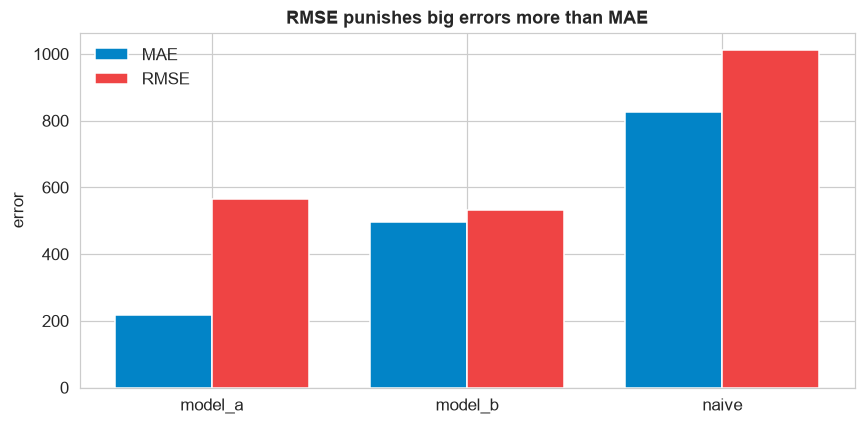

In [5]:
def mae(r): return np.abs(r).mean()
def rmse(r): return np.sqrt((r**2).mean())
tab = pd.DataFrame({c:{'MAE':mae(resid[c]),'MSE':(resid[c]**2).mean(),'RMSE':rmse(resid[c])} for c in resid}).T.round(0)
print(tab)
print('\nBy MAE: model_a wins (%.0f).  By RMSE: model_b EDGES model_a (%.0f vs %.0f)!' % (mae(resid['model_a']), rmse(resid['model_b']), rmse(resid['model_a'])))
print('why: model_a\'s single missed spike is squared by RMSE, so one big miss dominates.')
fig,ax=plt.subplots(figsize=(8,4)); x=np.arange(3); w=0.38
ax.bar(x-w/2,[mae(resid[c]) for c in resid],w,label='MAE',color=EM); ax.bar(x+w/2,[rmse(resid[c]) for c in resid],w,label='RMSE',color=RED)
ax.set_xticks(x); ax.set_xticklabels(list(resid)); ax.set(title='RMSE punishes big errors more than MAE', ylabel='error'); ax.legend(); plt.tight_layout(); plt.show()

These metrics use the error's own units. <strong>MAE</strong> (mean absolute error) treats every miss equally. <strong>MSE</strong> and its square root <strong>RMSE</strong> square the errors first, so a single large miss weighs far more. That is why the ranking <strong>flips</strong>: model_a wins on MAE (218 vs 496) but its one missed spike inflates its RMSE above model_b's (564 vs 532). <strong>RMSE is always at least MAE</strong>, and the gap grows with the spread of the errors. Choosing between them is really choosing how much a big miss should hurt.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">DEMO 3 &#183; PERCENTAGE, SCALED &amp; RELATIVE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">MAPE, sMAPE, MASE, Theil's U</div>
<div style="color:#4a5578;margin-top:6px">Scale-free scores you can compare across series.</div>
</div>

In [6]:
naive_mae = mae(resid['naive']); naive_rmse = rmse(resid['naive'])
def mape(f): r=a-f; return np.mean(np.abs(r/a))*100
def smape(f): r=a-f; return np.mean(2*np.abs(r)/(np.abs(a)+np.abs(f)))*100
rows=[]
for c in ['model_a','model_b','naive']:
    f=df[c].values; r=resid[c]
    rows.append({'model':c,'MAPE_%':round(mape(f),2),'sMAPE_%':round(smape(f),2),'MASE':round(mae(r)/naive_mae,2),'Theil_U':round(rmse(r)/naive_rmse,2)})
print(pd.DataFrame(rows).to_string(index=False))
print('\nMASE / Theil U below 1 => beats the naive benchmark. Both models do; naive is 1.00 by definition.')

  model  MAPE_%  sMAPE_%  MASE  Theil_U
model_a    2.85     3.04  0.26     0.56
model_b    7.16     7.46  0.60     0.53
  naive   11.73    12.71  1.00     1.00

MASE / Theil U below 1 => beats the naive benchmark. Both models do; naive is 1.00 by definition.


To compare across products or scales you need <strong>unit-free</strong> scores. <strong>MAPE</strong> averages the percentage error, intuitive, but it blows up near zero and punishes over- and under-forecasts asymmetrically; <strong>sMAPE</strong> softens that. <strong>MASE</strong> and <strong>Theil's U</strong> are <strong>relative to the naive benchmark</strong>: below 1 means you beat naive, above 1 means you did worse than doing nothing. Both models clear the bar (MASE 0.26 and 0.60), which is the first thing any forecast must prove.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">DEMO 4 &#183; COMPARING MODELS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Is A really better than B?</div>
<div style="color:#4a5578;margin-top:6px">The Diebold-Mariano test, and residual checks.</div>
</div>

In [7]:
def dm_test(a, f1, f2, h=1):
    d=(a-f1)**2 - (a-f2)**2; n=len(d); dbar=d.mean(); var=np.mean((d-dbar)**2)
    for k in range(1,h): var += 2*(1-k/h)*np.mean((d[k:]-dbar)*(d[:-k]-dbar))
    stat=dbar/np.sqrt(var/n); return stat, 2*(1-stats.norm.cdf(abs(stat)))
s,p = dm_test(a, df['model_a'].values, df['model_b'].values)
print('Diebold-Mariano  A vs B (squared-error loss): stat %.2f, p = %.3f' % (s,p))
print('p > 0.05 -> the RMSE gap between A and B is NOT statistically significant (driven by one spike).')
lb = acorr_ljungbox(resid['model_a'], lags=[6])['lb_pvalue'].iloc[0]
print('\nmodel_a residual Ljung-Box p = %.2f -> %s' % (lb, 'no leftover autocorrelation (good)' if lb>0.05 else 'structure remains'))

Diebold-Mariano  A vs B (squared-error loss): stat 0.13, p = 0.897
p > 0.05 -> the RMSE gap between A and B is NOT statistically significant (driven by one spike).

model_a residual Ljung-Box p = 0.99 -> no leftover autocorrelation (good)


A ranking is only as good as its reliability. The <strong>Diebold-Mariano test</strong> asks whether two forecasts' errors differ <em>significantly</em>. Here A vs B gives <strong>p about 0.90</strong>: the RMSE gap is <strong>not statistically distinguishable</strong>, it hangs on that one spike, so you should not crown B on RMSE alone. Good practice also checks the residuals: model_a's pass a <strong>Ljung-Box</strong> test (no leftover autocorrelation), meaning there is no obvious signal it failed to use.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">DEMO 5 &#183; THE VERDICT</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">One panel, one decision</div>
<div style="color:#4a5578;margin-top:6px">Read the metric that matches your cost.</div>
</div>

In [8]:
panel=[]
for c in ['model_a','model_b','naive']:
    f=df[c].values; r=resid[c]
    panel.append({'model':c,'ME':round(r.mean()),'MAE':round(mae(r)),'RMSE':round(rmse(r)),'MAPE%':round(mape(f),1),'MASE':round(mae(r)/naive_mae,2)})
print(pd.DataFrame(panel).to_string(index=False))
print('\nTypical-accuracy view (MAE, MAPE): model_a wins clearly.')
print('Large-miss-averse view (RMSE): A and B tie, because one spike dominates.')
print('Both beat naive. If missing rare spikes is costly, invest in catching them; otherwise ship model_a.')

  model  ME  MAE  RMSE  MAPE%  MASE
model_a  84  218   564    2.8  0.26
model_b 496  496   532    7.2  0.60
  naive 827  827  1013   11.7  1.00

Typical-accuracy view (MAE, MAPE): model_a wins clearly.
Large-miss-averse view (RMSE): A and B tie, because one spike dominates.
Both beat naive. If missing rare spikes is costly, invest in catching them; otherwise ship model_a.


There is no single &#8220;accuracy&#8221; number. On <strong>typical</strong> accuracy (MAE, MAPE) model_a is the clear winner; if a single <strong>large miss</strong> is what hurts (RMSE), A and B are a toss-up. The right call follows the <strong>cost of your errors</strong>: report several metrics, check they agree, test the difference, and pick the metric that mirrors the decision.

## The accuracy toolkit, in one view

1. **ME** measures bias (a systematic lean), not accuracy; near-zero can still hide cancelling errors.
2. **MAE / MSE / RMSE** are scale-dependent; RMSE punishes big misses hardest (RMSE always at least MAE).
3. **MAPE / sMAPE** are percentage errors, comparable across scales but fragile near zero.
4. **MASE / Theil's U** score you against the naive benchmark, below 1 is the bar every forecast must clear.
5. **Diebold-Mariano** tests whether one model is significantly better, a ranking gap can be noise.

**The one idea to keep: a forecast metric is a loss function in disguise, so choosing a metric is choosing which errors you refuse to tolerate, and the honest report shows several, confirms they agree, and tests the difference.**

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>